# Supervised Bot Detection — Input Features (Mouse Behavior)

Train a supervised classifier to replace the `IsolationForest` used in the input pipeline.  
Ground-truth labels come from the `source` field written by the selenium bot simulator:  
`human`, `bot_linear`, `bot_direct`, `bot_scan`, `bot_burst`, `bot_cautious`.

Two modes are explored:
- **Binary**: `human` (0) vs any bot (1)  
- **Multi-class**: one class per source label

## 1. Import Required Libraries

In [65]:
import json, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load, dump
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score, f1_score,
)

RANDOM_STATE = 42
DATA_DIR = pathlib.Path("../../data")
FEATURES_JSONL = DATA_DIR / "features" / "input_features.jsonl"

## 2. Load Labeled Data

Load `input_features.jsonl`. Each record has a `features` dict (25 mouse-behavior values) and a `source` field that serves as the ground-truth label.

In [66]:
records = [json.loads(line) for line in FEATURES_JSONL.read_text().splitlines() if line.strip()]

df = pd.DataFrame([r["features"] for r in records])
df["source"] = [r.get("source", "human") for r in records]

print(f"Total records : {len(df)}")
print(f"\nClass counts (source):")
print(df["source"].value_counts())
df.head(3)

Total records : 492

Class counts (source):
source
human           372
bot_direct       24
bot_linear       24
bot_scan         24
bot_burst        24
bot_cautious     24
Name: count, dtype: int64


,entropy_direction,entropy_speed,speed_variance,max_speed,mean_acceleration,path_efficiency,direction_changes,mean_turning_angle,std_turning_angle,constant_speed_ratio,...,identical_interval_ratio,field_min_duration,field_avg_duration,fields_filled,scroll_depth_max,scroll_event_rate,scroll_direction_changes,session_duration,scroll_click_ratio,source
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,human
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,human
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,human


## 3. Exploratory Data Analysis

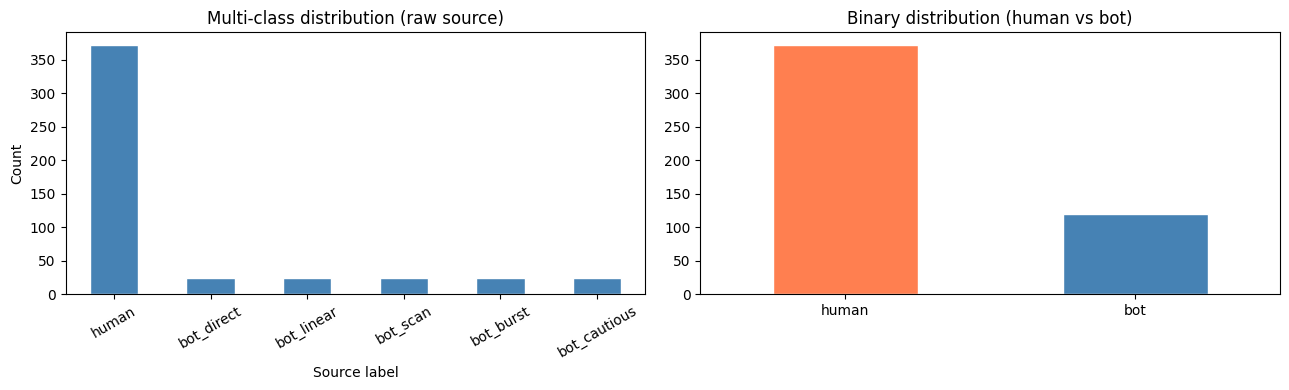

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["source"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Multi-class distribution (raw source)")
axes[0].set_xlabel("Source label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

binary_counts = df["source"].map(lambda s: "human" if s == "human" else "bot").value_counts()
binary_counts.plot(kind="bar", ax=axes[1], color=["coral", "steelblue"], edgecolor="white")
axes[1].set_title("Binary distribution (human vs bot)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

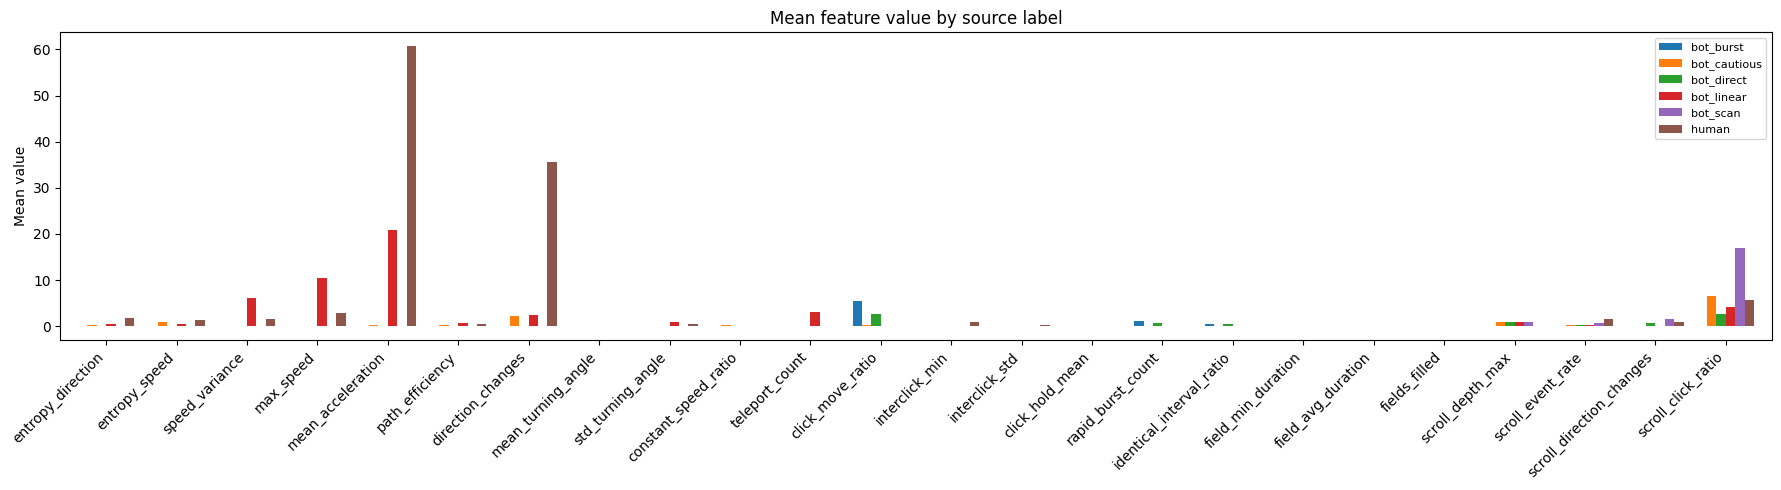

In [68]:

# session_duration is excluded: it is a simulator artifact (fixed batches × fixed interval)
# and not a genuine mouse-behaviour signal — see section 11 for the leakage audit.
FEATURE_COLS = [c for c in df.columns if c not in ("source", "session_duration")]

means = df.groupby("source")[FEATURE_COLS].mean().T
means.plot(kind="bar", figsize=(18, 5), width=0.8)
plt.title("Mean feature value by source label")
plt.ylabel("Mean value")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 4. Preprocessing

Build **binary** labels (`human=0`, `bot=1`).  
Change `BINARY_MODE = False` to keep per-persona multi-class labels instead.

In [69]:
BINARY_MODE = True  # True → human vs bot  |  False → per-persona multi-class

X = df[FEATURE_COLS].values

if BINARY_MODE:
    raw_labels = df["source"].map(lambda s: "human" if s == "human" else "bot").values
else:
    raw_labels = df["source"].values

le = LabelEncoder()
y = le.fit_transform(raw_labels)

print(f"Mode    : {'binary' if BINARY_MODE else 'multi-class'}")
print(f"Classes : {list(le.classes_)}")
print(f"Encoded : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Shape   : X={X.shape}  y={y.shape}")

Mode    : binary
Classes : ['bot', 'human']
Encoded : {'bot': np.int64(0), 'human': np.int64(1)}
Shape   : X=(492, 24)  y=(492,)


## 5. Train / Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
for cls, name in enumerate(le.classes_):
    tr = (y_train == cls).sum()
    te = (y_test  == cls).sum()
    print(f"  {name:20s}  train={tr:4d}  test={te:3d}")

Train : (393, 24)  |  Test : (99, 24)
  bot                   train=  96  test= 24
  human                 train= 297  test= 75


## 6. Model Training

Compare three classifiers with 5-fold stratified cross-validation.

In [71]:
candidates = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  F1-weighted = {scores.mean():.4f} ± {scores.std():.4f}")

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nBest candidate: {best_name}")

LogisticRegression         F1-weighted = 0.9550 ± 0.0142
RandomForest               F1-weighted = 0.9550 ± 0.0142
GradientBoosting           F1-weighted = 0.9522 ± 0.0166

Best candidate: LogisticRegression


## 7. Evaluation on Test Set

Test accuracy : 0.9596

              precision    recall  f1-score   support

         bot       1.00      0.83      0.91        24
       human       0.95      1.00      0.97        75

    accuracy                           0.96        99
   macro avg       0.97      0.92      0.94        99
weighted avg       0.96      0.96      0.96        99



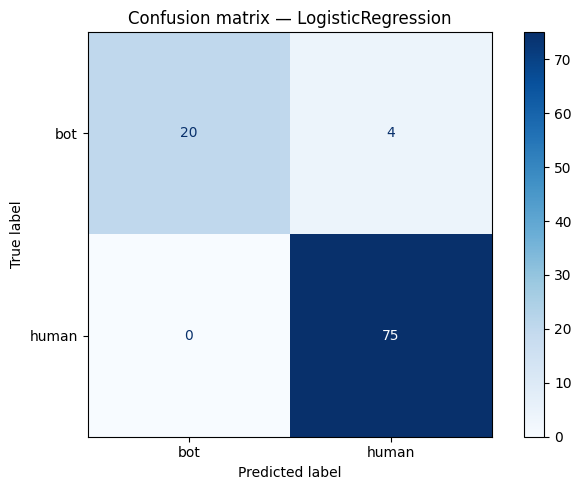

In [72]:
best_pipe = candidates[best_name]
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print(f"Test accuracy : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=list(le.classes_)))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=list(le.classes_),
    cmap="Blues", ax=ax,
)
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

In [ ]:
if hasattr(best_pipe, "predict_proba"):
    y_proba = best_pipe.predict_proba(X_test)
    n_cls = len(le.classes_)
    auc = roc_auc_score(
        y_test, y_proba if n_cls > 2 else y_proba[:, 1],
        multi_class="ovr" if n_cls > 2 else "raise",
        average="weighted" if n_cls > 2 else None,
    )
    print(f"ROC-AUC : {auc:.4f}")

clf = best_pipe.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    # Tree-based models (RandomForest, GradientBoosting)
    importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    title = f"Top-15 feature importances — {best_name}"
elif hasattr(clf, "coef_"):
    # Linear models (LogisticRegression): use absolute coefficient magnitude
    coef = clf.coef_[0] if clf.coef_.ndim > 1 else clf.coef_
    importances = pd.Series(np.abs(coef), index=FEATURE_COLS).sort_values(ascending=False)
    title = f"Top-15 feature importances (|coef|) — {best_name}"
else:
    importances = None

if importances is not None:
    importances.head(15).plot(kind="bar", figsize=(12, 4), color="teal", edgecolor="white")
    plt.title(title)
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()


ROC-AUC : 0.9778


## 8. Hyperparameter Tuning

`RandomizedSearchCV` (30 iterations, 5-fold stratified CV) on the winning candidate.

In [74]:
param_grids = {
    "LogisticRegression": {
        "clf__C":       [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__solver":  ["lbfgs", "saga"],
        "clf__penalty": ["l2"],
    },
    "RandomForest": {
        "clf__n_estimators":      [100, 200, 400, 600],
        "clf__max_depth":         [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__max_features":      ["sqrt", "log2", 0.5],
    },
    "GradientBoosting": {
        "clf__n_estimators":  [100, 200, 300, 500],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__max_depth":     [3, 5, 7],
        "clf__subsample":     [0.7, 0.8, 1.0],
    },
}

search = RandomizedSearchCV(
    candidates[best_name],
    param_distributions=param_grids[best_name],
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
search.fit(X_train, y_train)

print(f"\nBest params : {search.best_params_}")
print(f"Best CV F1  : {search.best_score_:.4f}")

tuned_pipe   = search.best_estimator_
y_pred_tuned = tuned_pipe.predict(X_test)
print(f"\nTuned test accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=list(le.classes_)))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\lknoe\Documents\Fac_2025_2026\Web mining\SISE-ChallengeWebMining\SISE-Challenge-WebMining\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best params : {'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__C': 0.1}
Best CV F1  : 0.9550

Tuned test accuracy : 0.9596
              precision    recall  f1-score   support

         bot       1.00      0.83      0.91        24
       human       0.95      1.00      0.97        75

    accuracy                           0.96        99
   macro avg       0.97      0.92      0.94        99
weighted avg       0.96      0.96      0.96        99



c:\Users\lknoe\Documents\Fac_2025_2026\Web mining\SISE-ChallengeWebMining\SISE-Challenge-WebMining\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 9. Save Final Model

Persist the tuned pipeline and the label encoder.  
The pipeline can be hot-swapped into `app/input_model/model_manager.py` as a drop-in replacement for the `IsolationForest`.

In [75]:
OUT_MODEL   = DATA_DIR / "models" / "supervised_input_classifier.joblib"
OUT_ENCODER = DATA_DIR / "models" / "supervised_input_label_encoder.joblib"

dump(tuned_pipe, OUT_MODEL)
dump(le,         OUT_ENCODER)

print(f"Pipeline saved → {OUT_MODEL}")
print(f"Encoder  saved → {OUT_ENCODER}")

Pipeline saved → ..\..\data\models\supervised_input_classifier.joblib
Encoder  saved → ..\..\data\models\supervised_input_label_encoder.joblib


In [76]:
reloaded    = load(OUT_MODEL)
reloaded_le = load(OUT_ENCODER)

for cls_name in reloaded_le.classes_:
    sample_idx = np.where(raw_labels == cls_name)[0][0]
    sample     = X[[sample_idx]]
    pred_enc   = reloaded.predict(sample)[0]
    pred_name  = reloaded_le.inverse_transform([pred_enc])[0]
    status     = "OK" if pred_name == cls_name else f"WRONG (got {pred_name})"
    print(f"  {cls_name:20s} → {pred_name:20s}  {status}")

  bot                  → bot                   OK
  human                → human                 OK


## 10. Comparison — IsolationForest vs Supervised Classifier

Evaluate the saved `IsolationForest` (unsupervised, one-class) against the tuned supervised pipeline on the **same test split**, using binary labels (human vs bot).

In [77]:
IF_PATH  = DATA_DIR / "models" / "isolation_forest.joblib"
if_model = load(IF_PATH)
print(f"Loaded IsolationForest from {IF_PATH}")

Loaded IsolationForest from ..\..\data\models\isolation_forest.joblib


Model                                  Accuracy   F1-weighted    ROC-AUC
------------------------------------------------------------------------
IsolationForest (unsupervised, 25f)      0.7980        0.8094     0.8100
Supervised — LogisticRegression (24f)      0.9596        0.9583     0.9167


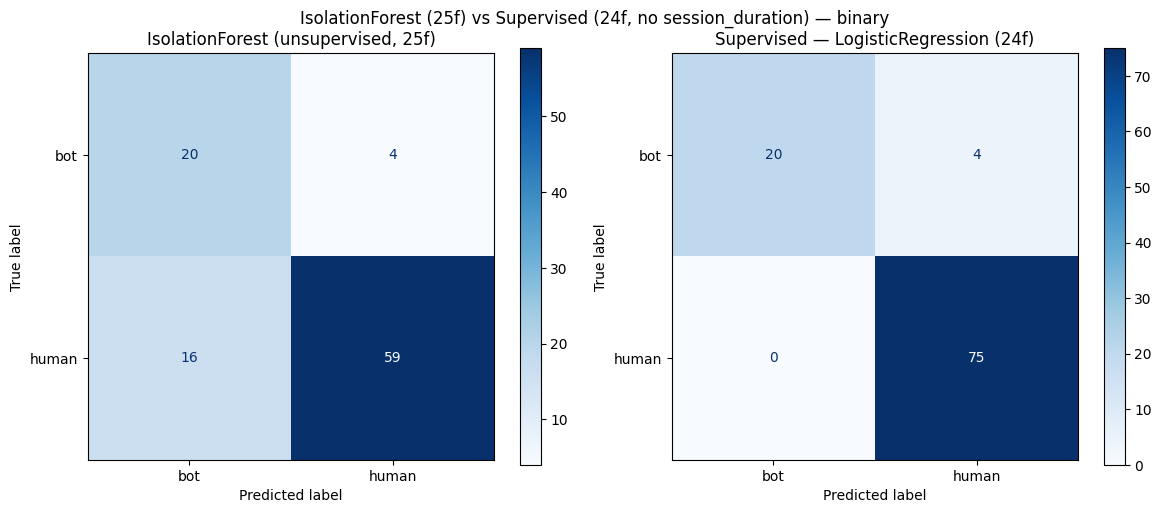

In [78]:

# The IsolationForest was trained on 25 features (app FEATURE_COLUMNS, which includes
# session_duration). The supervised model uses 24 features (session_duration excluded).
# We need separate test slices for each model, derived from the same split indices.

IF_FEATURE_COLS = FEATURE_COLS + ["session_duration"]   # 25 features, matches app model
X_full = df[IF_FEATURE_COLS].values

_, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_test_if = X_full[test_idx]   # 25 features → IsolationForest
# X_test (24 features) is already available from section 5 → supervised model

# Binary ground-truth for the test slice (always human vs bot)
binary_le     = LabelEncoder().fit(["bot", "human"])   # bot=0, human=1
y_binary_true = binary_le.transform(
    ["human" if raw_labels[i] == "human" else "bot" for i in test_idx]
)

# Supervised: collapse multi-class to binary if needed
sup_raw      = le.inverse_transform(tuned_pipe.predict(X_test))
y_sup_binary = binary_le.transform(["human" if s == "human" else "bot" for s in sup_raw])

# IsolationForest: +1 inlier (human), -1 outlier (bot)
if_raw      = if_model.predict(X_test_if)
y_if_binary = np.where(if_raw == 1,
                       binary_le.transform(["human"])[0],
                       binary_le.transform(["bot"])[0])

# Summary table
print(f"{'Model':<35}  {'Accuracy':>10}  {'F1-weighted':>12}  {'ROC-AUC':>9}")
print("-" * 72)
for model_name, y_pred_cmp in [
    ("IsolationForest (unsupervised, 25f)", y_if_binary),
    (f"Supervised — {best_name} (24f)",     y_sup_binary),
]:
    acc = accuracy_score(y_binary_true, y_pred_cmp)
    f1  = f1_score(y_binary_true, y_pred_cmp, average="weighted")
    auc = roc_auc_score(y_binary_true, y_pred_cmp)
    print(f"{model_name:<35}  {acc:>10.4f}  {f1:>12.4f}  {auc:>9.4f}")

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, y_pred_cmp in zip(
    axes,
    ["IsolationForest (unsupervised, 25f)", f"Supervised — {best_name} (24f)"],
    [y_if_binary, y_sup_binary],
):
    ConfusionMatrixDisplay.from_predictions(
        y_binary_true, y_pred_cmp,
        display_labels=binary_le.classes_,
        cmap="Blues", ax=ax,
    )
    ax.set_title(name)

plt.suptitle("IsolationForest (25f) vs Supervised (24f, no session_duration) — binary", fontsize=12)
plt.tight_layout()
plt.show()


## 11. Data Leakage Audit — `session_duration`

The selenium bot runs with a **fixed number of batches × fixed batch interval** (e.g. 5 × 10s = 50s per session).
The JS tracker fires every ~1s, so every bot record has `session_duration` ≤ 50s with discrete spikes at
multiples of `BATCH_INTERVAL_SEC`. Human sessions can last minutes with no ceiling.

This is a **dataset construction artifact** — a real bot that simply stays on the page longer would be
misclassified as human. `session_duration` has therefore been **removed from `FEATURE_COLS`** (cell 8).

The cell below plots the distribution to document why the removal was necessary.

C:\Users\lknoe\AppData\Local\Temp\ipykernel_16104\2035409484.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


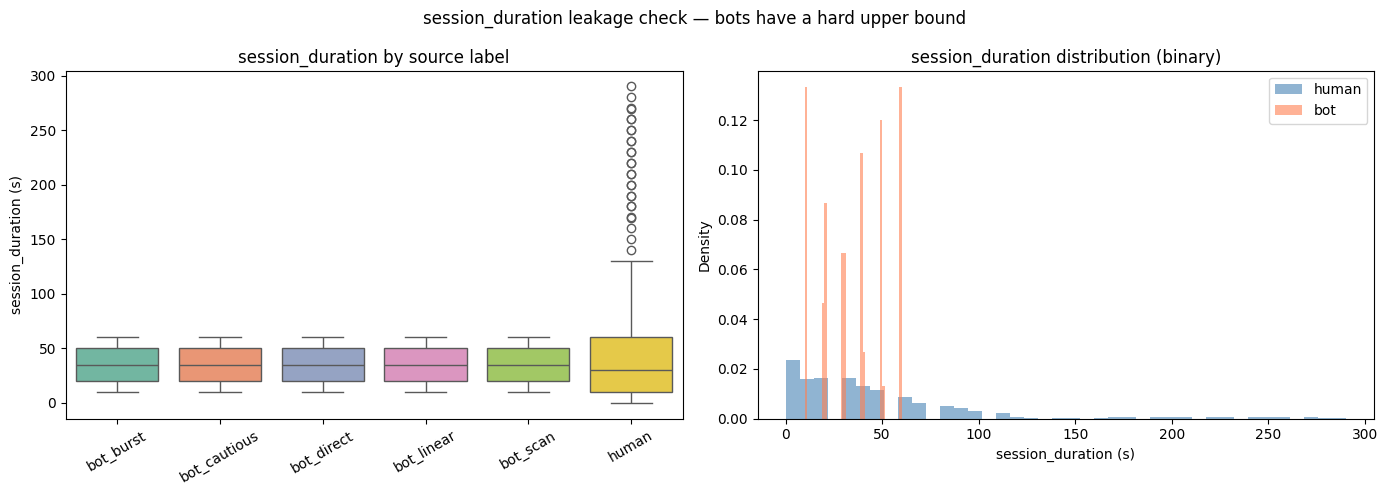

Max session_duration (bots)        : 60.0s
25th-pct session_duration (humans) : 10.0s

✓  Distributions overlap; leakage may be partial.


In [79]:
import seaborn as sns

# ── Distribution of session_duration by source label ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-persona box plot
sns.boxplot(
    data=df,
    x="source", y="session_duration",
    order=sorted(df["source"].unique()),
    palette="Set2", ax=axes[0],
)
axes[0].set_title("session_duration by source label")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("session_duration (s)")

# Binary overlapping histogram
for label, color in [("human", "steelblue"), ("bot", "coral")]:
    mask = df["source"] == label if label == "human" else df["source"] != "human"
    axes[1].hist(df.loc[mask, "session_duration"], bins=40, alpha=0.6,
                 color=color, label=label, density=True)
axes[1].set_title("session_duration distribution (binary)")
axes[1].set_xlabel("session_duration (s)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle("session_duration leakage check — bots have a hard upper bound", fontsize=12)
plt.tight_layout()
plt.show()

bot_max = df.loc[df["source"] != "human", "session_duration"].max()
human_q25 = df.loc[df["source"] == "human", "session_duration"].quantile(0.25)
print(f"Max session_duration (bots)        : {bot_max:.1f}s")
print(f"25th-pct session_duration (humans) : {human_q25:.1f}s")
if bot_max < human_q25:
    print("\n⚠  The two distributions barely overlap — trivial separation is possible with session_duration alone.")
else:
    print("\n✓  Distributions overlap; leakage may be partial.")


In [80]:

# session_duration has already been removed from FEATURE_COLS (cell 8).
# The model trained above IS the clean, leakage-free model.
# We confirm it here by showing its performance on the 24-feature set.

print(f"Feature set size : {len(FEATURE_COLS)} (session_duration removed)")
print(f"Features used    : {FEATURE_COLS}")
print()
print(f"CV F1 (mean)  : {cv_results[best_name].mean():.4f} ± {cv_results[best_name].std():.4f}")
print(f"Test accuracy : {accuracy_score(y_test, best_pipe.predict(X_test)):.4f}")
print()
print("This is the honest mouse-behaviour baseline — no session-length shortcut.")


Feature set size : 24 (session_duration removed)
Features used    : ['entropy_direction', 'entropy_speed', 'speed_variance', 'max_speed', 'mean_acceleration', 'path_efficiency', 'direction_changes', 'mean_turning_angle', 'std_turning_angle', 'constant_speed_ratio', 'teleport_count', 'click_move_ratio', 'interclick_min', 'interclick_std', 'click_hold_mean', 'rapid_burst_count', 'identical_interval_ratio', 'field_min_duration', 'field_avg_duration', 'fields_filled', 'scroll_depth_max', 'scroll_event_rate', 'scroll_direction_changes', 'scroll_click_ratio']

CV F1 (mean)  : 0.9550 ± 0.0142
Test accuracy : 0.9596

This is the honest mouse-behaviour baseline — no session-length shortcut.
